In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.transforms import v2
import os
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

In [13]:
# --- 1. KONFİGÜRASYON AYARLARI ---

# Cihazı ayarla (GPU varsa GPU, yoksa CPU kullan)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Kullanılan Cihaz: {DEVICE}")

# Veri setinin ana klasörü
DATA_DIR = "train_dataset"

# Model eğitimi için temel parametreler
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 30

# TAHMİN EŞİĞİ (THRESHOLD)
PREDICTION_THRESHOLD = 0.5

Kullanılan Cihaz: cuda


In [14]:
# --- 2. VERİ DÖNÜŞÜMLERİ (TRANSFORMS) ---

# Veri çoğaltma (augmentation) ve normalizasyon işlemleri
# EĞİTİM setine uygulanacak dönüşümler:
# Modelin her epoch'ta resmin farklı bir versiyonunu görmesini sağlar, ezberlemeyi önler.
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # %50 ihtimalle resmi yatayda çevir
    transforms.RandomRotation(10), # -10 ile +10 derece arasında rastgele döndür
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomApply([v2.JPEG(quality=(60, 100))], p=0.5),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))], p=0.3),
    transforms.ToTensor(), # Resmi PyTorch tensörüne çevir (Piksel değerlerini 0-1 arasına getirir)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet istatistikleri ile normalleştir
])

# VALIDATION ve TEST setlerine uygulanacak dönüşümler:
# Bu setlerde veri çoğaltma yapılmaz, çünkü modelin performansı tutarlı verilerle ölçülmelidir.
val_test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [15]:
# --- 3. VERİ YÜKLEYİCİLER (DATALOADERS) ---

# ImageFolder, klasör isimlerine göre etiketleri otomatik olarak atar (örn: fake=0, real=1)
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transforms)
validation_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "validation"), transform=val_test_transforms)
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_test_transforms)

# Verileri batch'ler halinde modele sunmak için DataLoader'lar oluşturulur
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
validation_loader = DataLoader(dataset=validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("\nVeri Seti Bilgileri:")
print(f"Eğitim seti: {len(train_dataset)} resim")
print(f"Doğrulama seti: {len(validation_dataset)} resim")
print(f"Test seti: {len(test_dataset)} resim")
print(f"Sınıflar: {train_dataset.classes}")


Veri Seti Bilgileri:
Eğitim seti: 40799 resim
Doğrulama seti: 7199 resim
Test seti: 11998 resim
Sınıflar: ['fake', 'real']


In [16]:
# --- 4. MODEL TANIMLAMALARI ---

# Seçenek 1: Kendi yazdığım CNN modeli
class KendiCNN(nn.Module):
    def __init__(self):
        super(KendiCNN, self).__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# Seçenek 2: Hazır bir model (ResNet18) ve Transfer Learning
def get_pretrained_model():
    # ImageNet üzerinde eğitilmiş ResNet18 modelini yükle
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # Önceden eğitilmiş konvolüsyon katmanlarının ağırlıklarını dondur (Aşırı öğrenmeyi engeller)
    for param in model.parameters():
        param.requires_grad = False

    # SADECE layer4'ü eğitime aç (AI/Real ayrımı için ince özellikleri öğrenebilmesi adına)
    for param in model.layer4.parameters():
        param.requires_grad = True
    
    # Modelin son katmanını (classifier) kendi problemimize göre değiştir
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.6), # Aşırı öğrenmeyi (overfitting) engellemek için Dropout eklendi
        nn.Linear(num_ftrs, 1) # Çıktıyı 1 yap (binary classification)
    )
    
    return model

In [17]:
# --- 5. EĞİTİM FONKSİYONU ---

def train_model(model, criterion, optimizer, train_loader, val_loader, epochs, model_save_path, scheduler=None):
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        start_time = time.time()
        
        # --- Eğitim Aşaması ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Eğitim]"):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE).float().unsqueeze(1)
            
            # set_to_none=True ile bellek temizliği hızlandırıldı
            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            
            # Doğruluk hesaplama (Eşik değeri standart 0.5)
            predicted = torch.sigmoid(outputs) > PREDICTION_THRESHOLD
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct_train / total_train

        # --- Doğrulama Aşaması ---
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Doğrulama]"):
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE).float().unsqueeze(1)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

                predicted = torch.sigmoid(outputs) > PREDICTION_THRESHOLD
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = correct_val / total_val
        
        # Metrikleri history sözlüğüne kaydet
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Eğer bir scheduler (zamanlayıcı) verildiyse, doğrulama kaybına bakarak adım at
        if scheduler is not None:
            scheduler.step(val_loss)
        
        end_time = time.time()
        epoch_duration = end_time - start_time

        print(f"Epoch {epoch+1}/{epochs} | Süre: {epoch_duration:.2f}s")
        print(f"Eğitim Loss: {epoch_loss:.4f} | Eğitim Acc: {epoch_acc:.4f}")
        print(f"Doğrulama Loss: {val_loss:.4f} | Doğrulama Acc: {val_acc:.4f}\n")

        # En iyi modeli kaydet
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), model_save_path)
            print(f"*** Yeni en iyi model kaydedildi: {model_save_path} (Doğrulama Acc: {best_val_acc:.4f}) ***\n")

    print("Eğitim tamamlandı.")
    return model_save_path, history

def plot_training_history(history, model_name="Model"):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # 1. Grafik: Loss (Kayıp) Değişimi
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Eğitim Loss', linewidth=2)
    plt.plot(epochs, history['val_loss'], 'r-', label='Doğrulama Loss', linewidth=2)
    plt.title(f'{model_name} - Eğitim ve Doğrulama Kaybı (Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. Grafik: Accuracy (Başarım) Değişimi
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Eğitim Accuracy', linewidth=2)
    plt.plot(epochs, history['val_acc'], 'r-', label='Doğrulama Accuracy', linewidth=2)
    plt.title(f'{model_name} - Eğitim ve Doğrulama Başarımı (Accuracy)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [18]:
# --- 6. TEST FONKSİYONU VE METRİKLER ---

def test_model(model, model_path, test_loader, class_names):
    model.load_state_dict(torch.load(model_path))
    model.to(DEVICE)
    model.eval()

    y_true = []
    y_pred = []
    
    print("\n--- Test Aşaması Başlatıldı ---")
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="[Test]"):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            
            predicted = torch.sigmoid(outputs) > PREDICTION_THRESHOLD

            # squeeze() yerine view(-1) kullanarak son batch 1 gelse bile çökmesini engelliyoruz
            y_true.extend(labels.cpu().view(-1).numpy())
            y_pred.extend(predicted.cpu().view(-1).numpy())

    print("\n--- Test Sonuçları ---")
    
    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Test Seti Başarımı (Accuracy): {accuracy:.4f}\n")

    # Classification Report (Precision, Recall, F1-Score)
    print("Sınıflandırma Raporu:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Karmaşıklık Matrisi (Confusion Matrix)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
    plt.ylabel('Gerçek Etiket')
    plt.xlabel('Tahmin Edilen Etiket')
    plt.show()

In [19]:
# Test sonuçlarını toplamak için boş bir liste oluşturalım.
# Her modelin eğitimi bittiğinde bu listeye eklenecek.
trained_models_info = []


==================== MODEL EĞİTİMİ BAŞLIYOR: CUSTOM ====================


Epoch 1/30 [Doğrulama]: 100%|██████████| 225/225 [02:26<00:00,  1.53it/s]


Epoch 1/30 | Süre: 1384.08s
Eğitim Loss: 0.5716 | Eğitim Acc: 0.7083
Doğrulama Loss: 0.5034 | Doğrulama Acc: 0.7639

*** Yeni en iyi model kaydedildi: train_dataset\best_model_custom.pth (Doğrulama Acc: 0.7639) ***



Epoch 2/30 [Doğrulama]: 100%|██████████| 225/225 [00:30<00:00,  7.28it/s]


Epoch 2/30 | Süre: 392.03s
Eğitim Loss: 0.5200 | Eğitim Acc: 0.7520
Doğrulama Loss: 0.4796 | Doğrulama Acc: 0.7755

*** Yeni en iyi model kaydedildi: train_dataset\best_model_custom.pth (Doğrulama Acc: 0.7755) ***



...

Epoch 28/30 | Süre: 415.96s
Eğitim Loss: 0.3295 | Eğitim Acc: 0.8602
Doğrulama Loss: 0.2717 | Doğrulama Acc: 0.8905

*** Yeni en iyi model kaydedildi: train_dataset\best_model_custom.pth (Doğrulama Acc: 0.8905) ***



Epoch 29/30 [Doğrulama]: 100%|██████████| 225/225 [00:27<00:00,  8.24it/s]


Epoch 29/30 | Süre: 417.31s
Eğitim Loss: 0.3230 | Eğitim Acc: 0.8628
Doğrulama Loss: 0.2813 | Doğrulama Acc: 0.8847



Epoch 30/30 [Doğrulama]: 100%|██████████| 225/225 [00:27<00:00,  8.10it/s]


Epoch 30/30 | Süre: 409.06s
Eğitim Loss: 0.3208 | Eğitim Acc: 0.8639
Doğrulama Loss: 0.2819 | Doğrulama Acc: 0.8818

Eğitim tamamlandı.


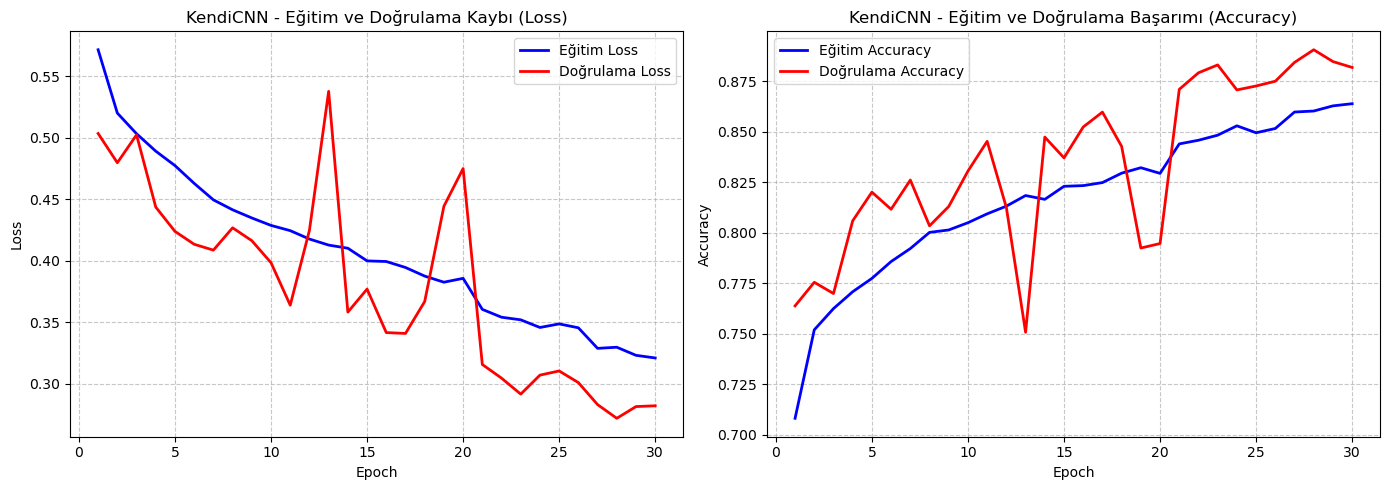


==================== MODEL EĞİTİMİ TAMAMLANDI: CUSTOM ====================


In [9]:
# --- 7. ÖZEL CNN MODELİNİN EĞİTİLMESİ (KendiCNN) ---

print(f"\n{'='*20} MODEL EĞİTİMİ BAŞLIYOR: CUSTOM {'='*20}")

custom_model = KendiCNN().to(DEVICE)

custom_criterion = nn.BCEWithLogitsLoss()
custom_optimizer = optim.Adam(custom_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
custom_scheduler = optim.lr_scheduler.ReduceLROnPlateau(custom_optimizer, mode='min', factor=0.5, patience=2)

custom_model_path, custom_history = train_model(
    custom_model, custom_criterion, custom_optimizer,
    train_loader, validation_loader,
    EPOCHS, os.path.join(DATA_DIR, "best_model_custom.pth"),
    scheduler=custom_scheduler
)

# Eğitimi biten modelin grafiklerini çizdir
plot_training_history(custom_history, model_name="KendiCNN")

trained_models_info.append({
    "name": "custom",
    "get_model": KendiCNN,
    "path": custom_model_path
})
print(f"\n{'='*20} MODEL EĞİTİMİ TAMAMLANDI: CUSTOM {'='*20}")


==================== MODEL EĞİTİMİ BAŞLIYOR: PRETRAINED ====================


Epoch 1/8 [Doğrulama]: 100%|██████████| 225/225 [00:35<00:00,  6.39it/s]


Epoch 1/8 | Süre: 425.75s
Eğitim Loss: 0.4384 | Eğitim Acc: 0.7907
Doğrulama Loss: 0.2968 | Doğrulama Acc: 0.8753

*** Yeni en iyi model kaydedildi: train_dataset\best_model_pretrained.pth (Doğrulama Acc: 0.8753) ***



Epoch 2/8 [Doğrulama]: 100%|██████████| 225/225 [00:30<00:00,  7.36it/s]


Epoch 2/8 | Süre: 488.49s
Eğitim Loss: 0.3392 | Eğitim Acc: 0.8519
Doğrulama Loss: 0.2659 | Doğrulama Acc: 0.8901

*** Yeni en iyi model kaydedildi: train_dataset\best_model_pretrained.pth (Doğrulama Acc: 0.8901) ***



...

Epoch 6/8 | Süre: 430.14s
Eğitim Loss: 0.2372 | Eğitim Acc: 0.9032
Doğrulama Loss: 0.2131 | Doğrulama Acc: 0.9132



Epoch 7/8 [Doğrulama]: 100%|██████████| 225/225 [00:30<00:00,  7.48it/s]


Epoch 7/8 | Süre: 438.52s
Eğitim Loss: 0.2180 | Eğitim Acc: 0.9112
Doğrulama Loss: 0.2027 | Doğrulama Acc: 0.9218

*** Yeni en iyi model kaydedildi: train_dataset\best_model_pretrained.pth (Doğrulama Acc: 0.9218) ***



Epoch 8/8 [Doğrulama]: 100%|██████████| 225/225 [00:35<00:00,  6.38it/s]


Epoch 8/8 | Süre: 448.45s
Eğitim Loss: 0.2060 | Eğitim Acc: 0.9156
Doğrulama Loss: 0.1995 | Doğrulama Acc: 0.9254

*** Yeni en iyi model kaydedildi: train_dataset\best_model_pretrained.pth (Doğrulama Acc: 0.9254) ***

Eğitim tamamlandı.


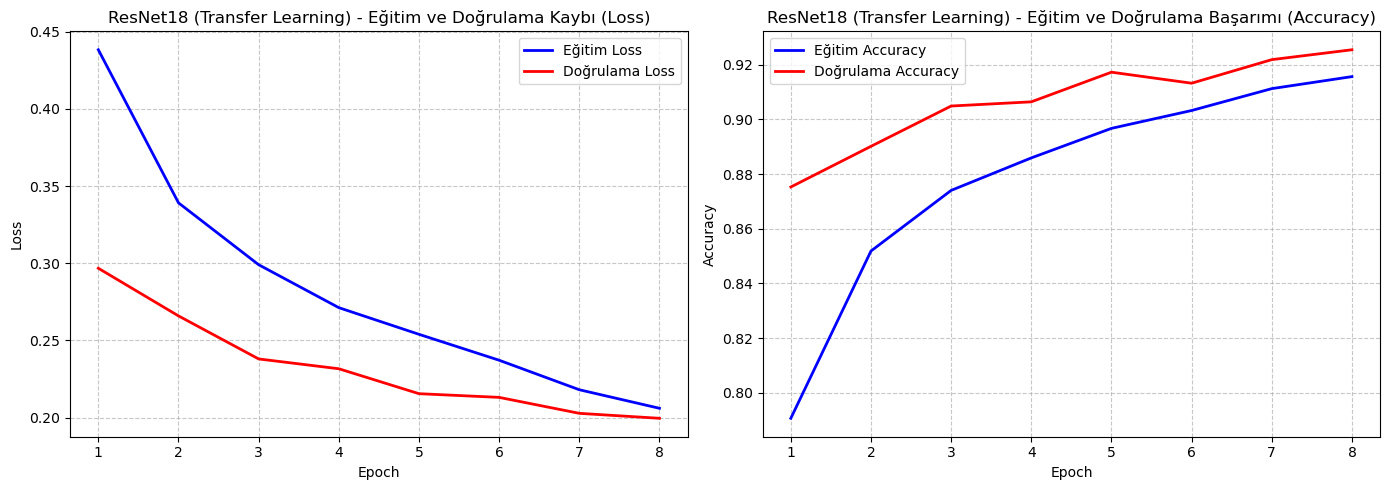


==================== MODEL EĞİTİMİ TAMAMLANDI: PRETRAINED ====================


In [20]:
# --- 8. HAZIR MODELİN EĞİTİLMESİ (ResNet18) ---

torch.cuda.empty_cache()

print(f"\n{'='*20} MODEL EĞİTİMİ BAŞLIYOR: PRETRAINED {'='*20}")

pretrained_model = get_pretrained_model().to(DEVICE)

pretrained_criterion = nn.BCEWithLogitsLoss()

# Differential Learning Rates (Farklı Öğrenme Oranları)
# layer4 için ÇOK DÜŞÜK, fc (yeni sınıflandırıcı) için NORMAL öğrenme oranı uyguluyoruz.
layer4_params = []
fc_params = []
for name, param in pretrained_model.named_parameters():
    if param.requires_grad:
        if 'layer4' in name:
            layer4_params.append(param)
        elif 'fc' in name:
            fc_params.append(param)

PRETRAINED_LR = 0.0005

pretrained_optimizer = optim.Adam([
    {'params': layer4_params, 'lr': 1e-5},  # Backbone kısmına çok küçük LR (Overfitting'i önler)
    {'params': fc_params, 'lr': PRETRAINED_LR} # Sınıflandırıcıya normal LR
], weight_decay=1e-3)
pretrained_scheduler = optim.lr_scheduler.ReduceLROnPlateau(pretrained_optimizer, mode='min', factor=0.5, patience=2)

pretrained_model_path, pretrained_history = train_model(
    pretrained_model, pretrained_criterion, pretrained_optimizer,
    train_loader, validation_loader,
    8, os.path.join(DATA_DIR, "best_model_pretrained.pth"),
    scheduler=pretrained_scheduler
)

# Eğitimi biten modelin grafiklerini çizdir
plot_training_history(pretrained_history, model_name="ResNet18 (Transfer Learning)")

trained_models_info.append({
    "name": "pretrained",
    "get_model": get_pretrained_model,
    "path": pretrained_model_path
})
print(f"\n{'='*20} MODEL EĞİTİMİ TAMAMLANDI: PRETRAINED {'='*20}")

C:\Users\volka\AppData\Local\Temp\ipykernel_11420\2360914697.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))




######################### KAYITLI MODELLERİN TEST SONUÇLARI #########################

--- Test Edilen Model: CUSTOM ---

--- Test Aşaması Başlatıldı ---


[Test]: 100%|██████████| 375/375 [00:43<00:00,  8.60it/s]


--- Test Sonuçları ---
Test Seti Başarımı (Accuracy): 0.8891

Sınıflandırma Raporu:
              precision    recall  f1-score   support

        fake       0.90      0.87      0.89      5998
        real       0.88      0.91      0.89      6000

    accuracy                           0.89     11998
   macro avg       0.89      0.89      0.89     11998
weighted avg       0.89      0.89      0.89     11998



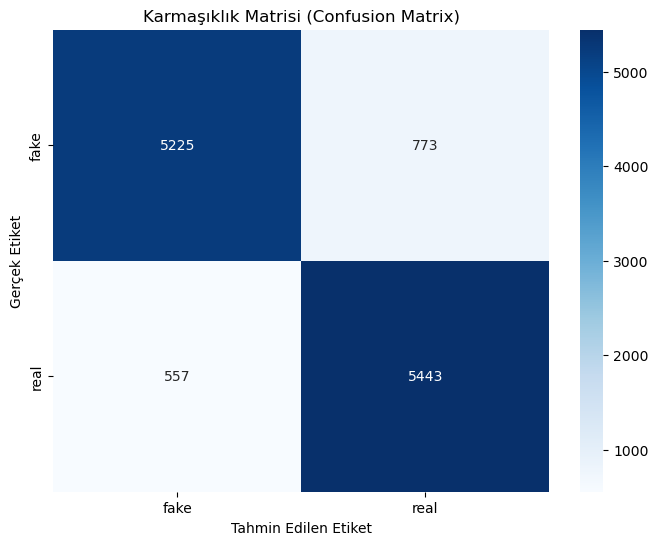


--- Test Edilen Model: PRETRAINED ---


C:\Users\volka\AppData\Local\Temp\ipykernel_11420\2360914697.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))



--- Test Aşaması Başlatıldı ---


[Test]: 100%|██████████| 375/375 [00:37<00:00,  9.90it/s]



--- Test Sonuçları ---
Test Seti Başarımı (Accuracy): 0.9248

Sınıflandırma Raporu:
              precision    recall  f1-score   support

        fake       0.92      0.93      0.92      5998
        real       0.93      0.92      0.92      6000

    accuracy                           0.92     11998
   macro avg       0.92      0.92      0.92     11998
weighted avg       0.92      0.92      0.92     11998



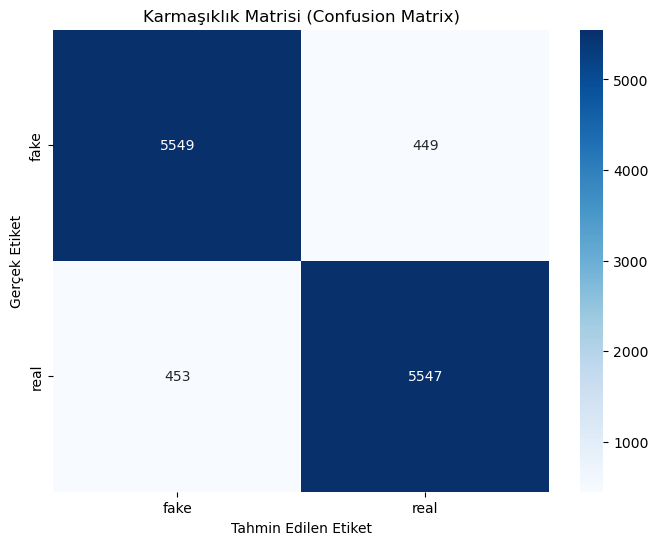

In [21]:
# --- 9. TEST VE SONUÇLARIN GÖSTERİLMESİ ---

print(f"\n\n{'#'*25} KAYITLI MODELLERİN TEST SONUÇLARI {'#'*25}")

# Rapor ve matriste kullanılacak sınıf isimlerini veri setinden al
class_names = train_dataset.classes

models_for_evaluation = [
    {
        "name": "custom",
        "get_model": KendiCNN,
        "path": os.path.join(DATA_DIR, "best_model_custom.pth")
    },
    {
        "name": "pretrained",
        "get_model": get_pretrained_model,
        "path": os.path.join(DATA_DIR, "best_model_pretrained.pth")
    }
]

for model_info in models_for_evaluation:
    # Modelin ağırlık dosyası var mı diye kontrol et
    if not os.path.exists(model_info["path"]):
        print(f"\n--- UYARI: Model dosyası bulunamadı, atlanıyor: {model_info['path']} ---")
        continue

    print(f"\n--- Test Edilen Model: {model_info['name'].upper()} ---")
    
    # Test için yeni bir model nesnesi oluştur ve en iyi ağırlıkları yükle
    test_model_instance = model_info["get_model"]()
    
    test_model(test_model_instance, model_info["path"], test_loader, class_names)

In [22]:
# --- 10. TEK BİR RESMİ TEST ETME (SINGLE IMAGE PREDICTION) ---

from PIL import Image

PREDICT_MODELS = [
    {
        "name": "custom",
        "get_model": KendiCNN,
        "path": os.path.join(DATA_DIR, "best_model_custom.pth")
    },
    {
        "name": "pretrained",
        "get_model": get_pretrained_model,
        "path": os.path.join(DATA_DIR, "best_model_pretrained.pth")
    }
]

CLASS_NAMES = ["fake", "real"]

def predict_single_image(image_path, models_info, class_names):
    if not os.path.exists(image_path):
        print(f"\nHata: Resim bulunamadı -> {image_path}")
        return

    try:
        img = Image.open(image_path).convert("RGB")
        
        transform = transforms.Compose([
            transforms.Resize((256, 256), Image.Resampling.LANCZOS),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        img_tensor = transform(img).unsqueeze(0).to(DEVICE)
        
        print(f"\n--- Tekil Resim Test Sonucu ---")
        print(f"Resim: {image_path}")
        print(f"{'Model':<15} | {'Tahmin':<10} | {'Güven Skoru'}")
        print("-" * 50)
        
        for model_info in models_info:
            model_name = model_info["name"].upper()
            model_path = model_info["path"]
            get_model_fn = model_info["get_model"]

            if not os.path.exists(model_path):
                print(f"{model_name:<15} | HATA: Model bulunamadı ({model_path})")
                continue

            # Modeli yükle
            model = get_model_fn()
            model.load_state_dict(torch.load(model_path, map_location=DEVICE))
            model.to(DEVICE)
            model.eval()
            
            with torch.no_grad():
                output = model(img_tensor)
                prob = torch.sigmoid(output).item()
                predicted_class = 1 if prob > PREDICTION_THRESHOLD else 0
                
            predicted_label = class_names[predicted_class]
            confidence = prob if predicted_class == 1 else 1 - prob
            
            print(f"{model_name:<15} | {predicted_label.upper():<10} | %{confidence*100:.2f}")
            
        print("-" * 50)
        
    except Exception as e:
        print(f"Resim işlenirken hata oluştu: {e}")

ornek_resim_yolu = "deneme/aasa.png"
predict_single_image(ornek_resim_yolu, PREDICT_MODELS, CLASS_NAMES)


--- Tekil Resim Test Sonucu ---
Resim: deneme/aasa.png
Model           | Tahmin     | Güven Skoru
--------------------------------------------------
CUSTOM          | FAKE       | %99.61


C:\Users\volka\AppData\Local\Temp\ipykernel_11420\2923834965.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=D

PRETRAINED      | FAKE       | %100.00
--------------------------------------------------
